# Formative - data analysis task 2024/2025

You have been given access to data on patients attending an opthalmology clinic for cataract surgery. 

The data contains pre-, intra- and post-operative data for patients (i.e. data measured before the operation, during the operation, and after the operation).

You are asked to predict those who are discharged from hospital within 24 hours of the operation (`discharge24`), using data available **at the conclusion of the operation**.
    
The folder on the VLE contains three files:
   * `training_data.csv` details of a subset of patients, with `discharge24` disclosed
   * `test_data.csv` details of a subset of patients with `discharge24` not disclosed
   * data_dictionary.gdoc - the data dictionary for these data.
   
You will need to pre-process the training and test datasets. You are asked to include a binary feature that represents whether a patient is overweight or not, based on body mass index (BMI). You should convert this continuous feature into a binary feature, using an appropriate threshold. 

You are asked to produce and compare **two** models for the task:
1. a decision tree model
2. a bagged ensemble model

Both models should be optimised your model on the training dataset using the **balanced accuracy score**  

The decision tree model is an interpretable model. Provide some **interpretability** of your bagged ensemble model. 

Based on your findings, choose one of your models to select as your final model. Provide a comment explaining your choice. 
   
Use your final model to predict the class label (i.e. predict `discharge24`) for those individuals in `test_data.csv`. **Save your predictions as** `y_predict`.

These predictions will be compared to `y_test` (i.e. the actual observed values for `discharge24`), which you do not have access to. The performance of your final model on the test data will contribute to your mark for this question.   

Your code should be commented, and you should also include text sections in your notebook providing additional background information and any references needed to explain your code.

The marking rubric is available here: https://docs.google.com/document/d/1OGZKaPKO61JOtGoPn_XT5bj2mqYksRxtFNg_irU7__g/edit?usp=sharing

When you have finished, download this notebook as an .ipynb format, and upload it to the submission point.

## Reading in Data

In [1]:
import pandas as pd

# reading in training data
train_data = pd.read_csv('training_data.csv')

# reading in test data
test_data = pd.read_csv('test_data.csv')

In [38]:
# checking the first few rows of the training data
train_data.head()

,patient_id,male,amd,hist_eye_trauma,glaucoma,myopia,retinal_tear_pre,diabetes,prev_surgery,both_eyes,...,endophthalmitis,retinal_tear_post,wound_leak,age,sats,respiratory_rate,prev_surgery_sr,bmi,lens_subluxation,discharge24
0,61069520,1,0,0.0,0.0,0.0,0,0.0,1.0,0,...,0,1.0,0,80.0,99,17,1,24.400000,NaN,1
1,99423217,1,0,0.0,0.0,NaN,0,0.0,0.0,0,...,0,NaN,0,55.0,97,17,0,22.900000,NaN,1
2,60225409,1,0,0.0,0.0,0.0,0,0.0,0.0,0,...,0,1.0,0,66.0,98,18,0,29.200001,NaN,1
3,97192422,1,1,0.0,1.0,0.0,0,0.0,0.0,0,...,0,1.0,0,60.0,97,18,0,31.299999,NaN,0
4,83176879,0,1,0.0,0.0,NaN,0,0.0,0.0,0,...,0,0.0,0,NaN,95,13,0,28.000000,NaN,1


In [3]:
# dropping discharge24 from the training data to make X_train and y_train
X_train = train_data.drop(columns=['discharge24'])
y_train = train_data['discharge24']

# creating X_test too
X_test = test_data.copy()

## Checking Missing Data and Class Imbalance

<Axes: >

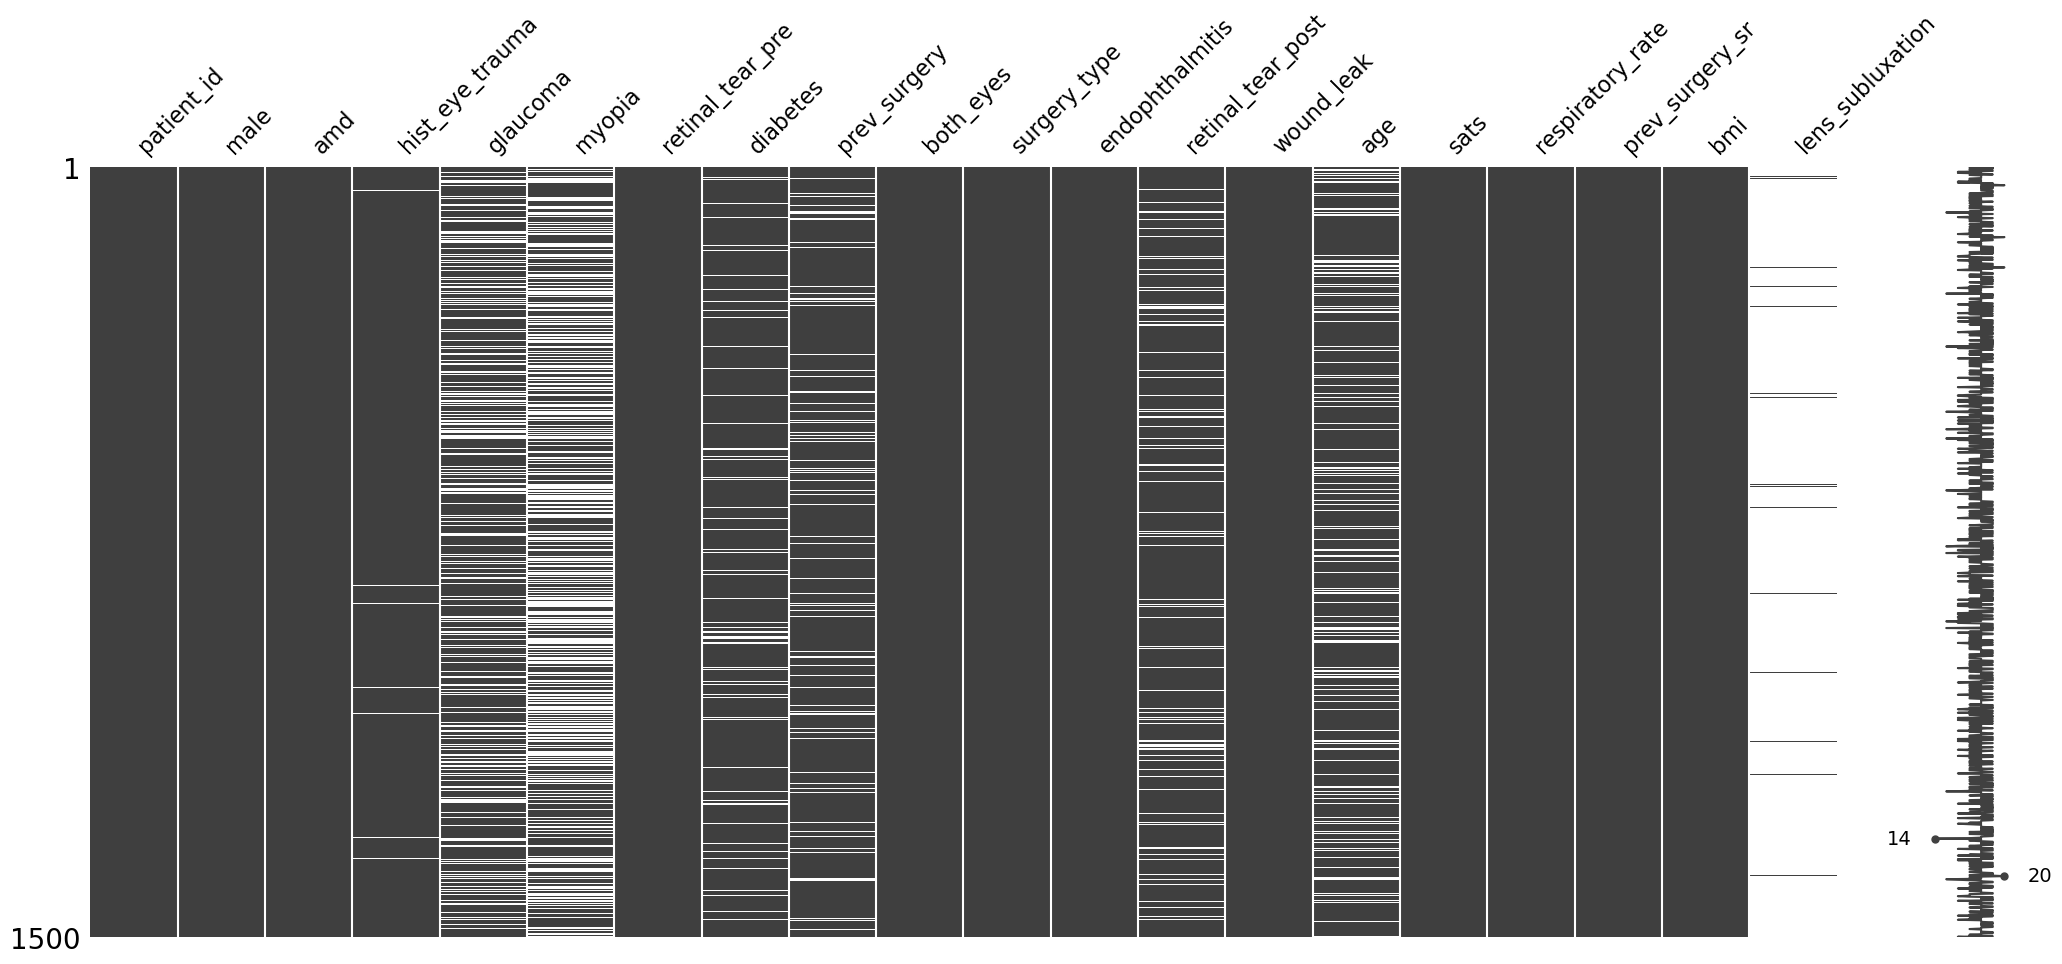

In [6]:
# visualising missing data in the training set
import missingno as msno

msno.matrix(X_train)

# lens_sublaxation is almost completely missing, so will drop it from the training data
# hist_eye_trauma, glaucoma, myopia, diabetes, and prev_surgery are binary features
# age is a continuous feature
# these may need to be imputed differently 

<Axes: xlabel='discharge24'>

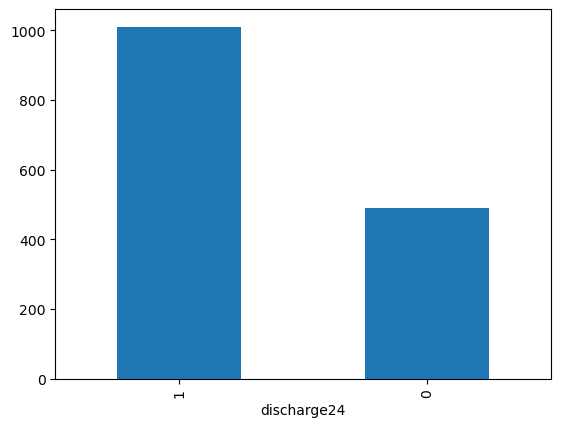

In [8]:
# plotting the number of 1 vs 0 in y_train to check for class imbalance
y_train.value_counts().plot(kind='bar')

# there is some class imbalance but not extreme, and balanced accuracy will give equal weight to both classes

## Features to Drop

In [19]:
# endophthalmitis, retinal_tear_post, and wound_leak are all post-op future outcomes, so including them in the training data would cause temporal leakage
# patient_id also needs removing and lens_subluxation as it is mostly missing, and bmi as we are creating the new overweight feature
# creating a function to drop these columns from the training data in the preprocessing pipeline
from sklearn.preprocessing import FunctionTransformer

def drop_columns(X):
    X = X.copy()
    return X.drop(columns=['patient_id', 'endophthalmitis', 'retinal_tear_post', 'wound_leak', 'lens_subluxation'])

column_dropper = FunctionTransformer(drop_columns)

## Overweight BMI Binary Feature

A BMI of 25 or above is the NHS' threshold for being classed as overweight

https://www.nhs.uk/conditions/obesity/

In [20]:
# converting the BMI column into a binary overweight column where 1 is overweight and 0 is not overweight
def convert_bmi_to_overweight(X):
    X = X.copy()
    X['overweight'] = (X['bmi'] >= 25).astype(int)
    return X.drop(columns=['bmi'])

bmi_converter = FunctionTransformer(convert_bmi_to_overweight)

## Preprocessing Pipeline

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
# setting the output of transformations to be pandas dataframes
# this will ensure that after imputation/scaling, the output is still a pandas dataframe
from sklearn import set_config
set_config(transform_output="pandas") 

preprocessing_pipeline = make_pipeline(
    column_dropper,
    bmi_converter,
    SimpleImputer(strategy='median')
)

## Decision Tree Pipeline

In [22]:
# creating a pipeline for a decision tree model
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = make_pipeline(
    preprocessing_pipeline,
    DecisionTreeClassifier(random_state=1)
)

Cross-validated accuracy scores: [0.73727016 0.7255001  0.79293797 0.7725298  0.79819155]
Mean cross-validated accuracy: 0.7652859163467367


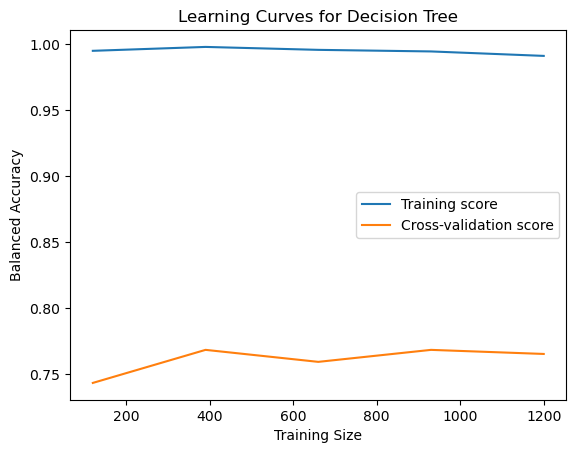

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# fitting the decision tree pipeline to the training data
decision_tree_pipeline.fit(X_train, y_train)

# cross validating the decision tree pipeline
dt_cv_scores = cross_val_score(decision_tree_pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
print(f'Cross-validated accuracy scores: {dt_cv_scores}')
print(f'Mean cross-validated accuracy: {dt_cv_scores.mean()}')

# printing learning curves for the decision tree pipeline
train_sizes, train_scores, test_scores = learning_curve(decision_tree_pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')

plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training Size')
plt.ylabel('Balanced Accuracy')
plt.title('Learning Curves for Decision Tree')
plt.legend()
plt.show()

The learning curve does not look like a healthy decision tree - balanced training accuracy is fixed almost exactly at 100% and balanced CV accuracy does not improve with training size

## Decision Tree Optimisation

In [ ]:
# random search to find optimal decision tree hyperparameters - optimising for balanced accuracy
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'decisiontreeclassifier__max_depth': [None, 5, 10, 20],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 4]
}

dt_random_search = RandomizedSearchCV(decision_tree_pipeline, 
                                      param_distributions=param_dist, 
                                      n_iter=10, 
                                      cv=5, 
                                      scoring='balanced_accuracy', 
                                      random_state=1)

dt_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('pipeline',
                                              Pipeline(steps=[('functiontransformer-1',
                                                               FunctionTransformer(func=<function drop_columns at 0x000002BAF4714680>)),
                                                              ('functiontransformer-2',
                                                               FunctionTransformer(func=<function convert_bmi_to_overweight at 0x000002BAF4714360>)),
                                                              ('simpleimputer',
                                                               SimpleImputer(strategy='median'))])),
                                             ('decisiontreeclassifier',
                                              DecisionTreeClassifier(random_state=1))]),
                   param_distributions={'decisiontreeclassifier__max_depth': [None,
                                                                              5,
                                                                              10,
                                                                              20],
                                        'decisiontreeclassifier__min_samples_leaf': [1,
                                                                                     2,
                                                                                     4],
                                        'decisiontreeclassifier__min_samples_split': [2,
                                                                                      5,
                                                                                      10]},
                   random_state=1, scoring='balanced_accuracy')

Cross-validated balanced accuracy scores with best hyperparameters: [0.82264094 0.82016569 0.81955951 0.82248939 0.84582744]
Mean cross-validated balanced accuracy with best hyperparameters: 0.8261365932511617


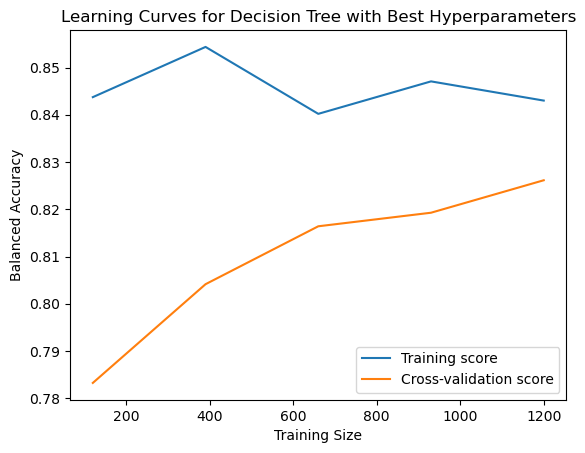

In [36]:
# re-running cross validation with the best hyperparameters from random search
best_dt_pipeline = dt_random_search.best_estimator_
best_dt_cv_scores = cross_val_score(best_dt_pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
print(f'Cross-validated balanced accuracy scores with best hyperparameters: {best_dt_cv_scores}')
print(f'Mean cross-validated balanced accuracy with best hyperparameters: {best_dt_cv_scores.mean()}')

# plotting learning curves for the decision tree with the best hyperparameters
train_sizes, train_scores, test_scores = learning_curve(best_dt_pipeline, X_train, y_train, cv=5, scoring='balanced_accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training Size')
plt.ylabel('Balanced Accuracy')
plt.title('Learning Curves for Decision Tree with Best Hyperparameters')
plt.legend()
plt.show()

This looks like a healthier decision tree, and more generalisable to unseen data as balanced CV accuracy increases with training size and training balanced accuracy decreases, suggesting less overfitting

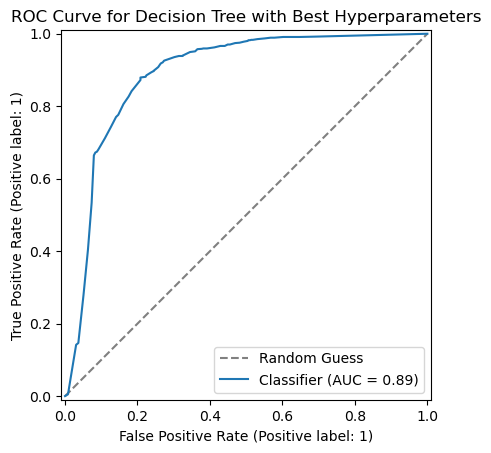

In [34]:
# creating roc-auc curve for the decision tree with the best hyperparameters
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_predict
fig, ax = plt.subplots()

# plotting the ROC-AUC curves for all three models and a random guess line
ax.plot([0, 1], [0, 1], linestyle='--', label='Random Guess', color = 'grey')

# getting the predicted probabilities for the training data using cross_val_predict with method='predict_proba' to avoid overfitting
y_train_proba = cross_val_predict(best_dt_pipeline, X_train, y_train, cv=5, method='predict_proba')[:, 1]

RocCurveDisplay.from_predictions(y_train, y_train_proba, ax=ax)
ax.set_title('ROC Curve for Decision Tree with Best Hyperparameters')
plt.show()


              precision    recall  f1-score   support

           0       0.83      0.73      0.77       490
           1       0.87      0.93      0.90      1010

    accuracy                           0.86      1500
   macro avg       0.85      0.83      0.84      1500
weighted avg       0.86      0.86      0.86      1500



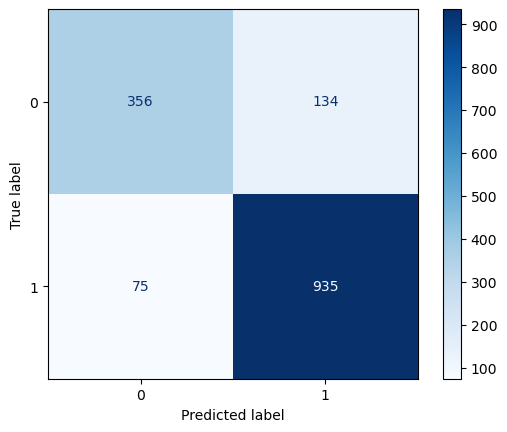

In [35]:
# creating classification report for the decision tree with the best hyperparameters
from sklearn.metrics import classification_report

# using cross_val_predict with method='predict' to get the predicted classes for the training data without overfitting
y_train_pred = cross_val_predict(best_dt_pipeline, X_train, y_train, cv=5, method='predict')
print(classification_report(y_train, y_train_pred))

# creating confusion matrix for the decision tree with the best hyperparameters
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap='Blues')

## Interpretable Model

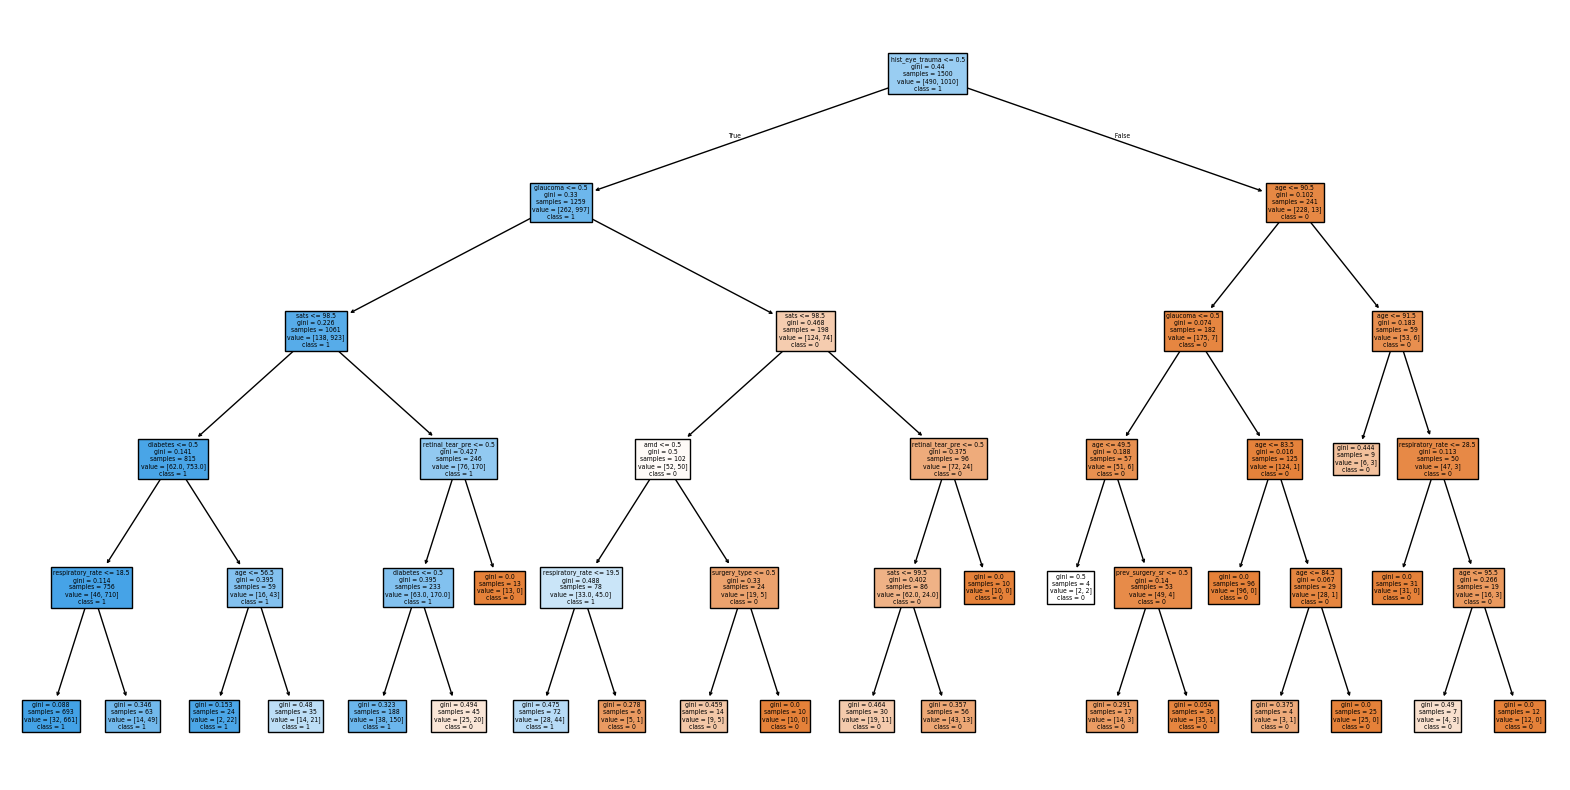

In [ ]:
# printing out the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

feature_names = best_dt_pipeline.named_steps['pipeline'].transform(X_train.head(1)).columns

plot_tree(
    best_dt_pipeline.named_steps['decisiontreeclassifier'],
    filled=True,
    feature_names=feature_names,
    class_names=['0', '1']
)

plt.show()

**You will not be able to run the code below as you do not have access to `y_test`**. 

In [ ]:
# do not run this code
y_test = pd.read_csv("y_test.csv")

balanced_accuracy = balanced_accuracy_score(y_true = y_test, y_pred = y_predict)

print(f'Final balanced accuracy: {balanced_accuracy:.6f}')